In [8]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import os
import torch
import numpy as np
import warnings
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)

from configs.default_config import Config
from envs.hems_env import EnergyStorageEnv
from common.replay_buffer import ReplayBuffer
from madrl.maddpg import MADDPG
from madrl.matd3 import MATD3
from common.vec_env import DummyVecEnv


# =========================
# 0) 初始化配置（关键：保证 env 的 K=24 要求）
# =========================
args = Config()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: cuda


In [9]:
# =========================
# 1) 工具函数：画 reward 分解 & 画轨迹
# =========================
def plot_reward_decomposition(history, episode_rewards, title, window=20):
    """画 Total + 5个分量（按总reward中的符号贡献）"""
    if len(history) == 0:
        print("No history to plot.")
        return

    ep_total = np.array(episode_rewards, dtype=np.float32)

    # 注意：pen/soc 在总 reward 中是减号，所以我们画 contribution 时取负号
    ep_inc   = np.array([np.sum(ep["r_inc_sum"]) for ep in history], dtype=np.float32)
    ep_pen   = np.array([np.sum(ep["r_pen_sum"]) for ep in history], dtype=np.float32)  # 已经是“负贡献”
    ep_pbrs  = np.array([np.sum(ep["r_pbrs_sum"]) for ep in history], dtype=np.float32)
    ep_soc   = np.array([np.sum(ep["r_soc_sum"]) for ep in history], dtype=np.float32)  # 已经是“负贡献”
    ep_bonus = np.array([np.sum(ep["r_bonus_sum"]) for ep in history], dtype=np.float32)

    fig, axs = plt.subplots(6, 1, figsize=(10, 10), sharex=True)
    fig.suptitle(title, fontsize=15)

    def _plot(ax, data, color, name):
        ma = pd.Series(data).rolling(window=window, min_periods=1).mean()
        ax.plot(ma, color=color, linewidth=2, label=f"MA({window})")
        ax.set_title(name)
        ax.grid(True, linestyle=":")
        ax.axhline(0, color="black", linewidth=0.5)
        ax.legend(loc="best")

    _plot(axs[0], ep_total, "red",    "1) Episode Total Reward (sum over agents)")
    _plot(axs[1], ep_inc,   "green",  "2) + r_inc (incremental cost)")
    _plot(axs[2], ep_pen,   "orange", "3) - r_pen (action penalty contribution)")
    _plot(axs[3], ep_pbrs,  "blue",   "4) + r_pbrs (PBRS)")
    _plot(axs[4], ep_soc,   "purple", "5) - r_soc (SoC regularization contribution)")
    _plot(axs[5], ep_bonus, "teal",   "6) + r_bonus (throughput bonus)")

    axs[-1].set_xlabel("Episode")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_last_k_episodes_price_action_soc(history, k=2, n_agents=3, title_prefix="Train"):
    """画最后 k 个 episode：子图1电价；子图2..N+1 各agent电池功率(e_bat)柱状 + SOC折线"""
    if len(history) == 0:
        print("No history to plot.")
        return

    k = min(k, len(history))
    start = len(history) - k

    for ep_idx in range(start, len(history)):
        ep = history[ep_idx]
        price = np.asarray(ep["price"], dtype=np.float32)            # (T,)
        T = len(price)
        ts = np.arange(T)

        fig, axs = plt.subplots(1 + n_agents, 1, figsize=(11, 2.4 * (1 + n_agents)), sharex=True)
        fig.suptitle(f"{title_prefix} Episode {ep_idx + 1}: Price + Battery Power & SOC", fontsize=14, y=0.995)

        # 1) price
        ax0 = axs[0]
        ax0.plot(ts, price, color="m", linewidth=2, label="Price")
        ax0.set_title("Price")
        ax0.set_ylabel("Price")
        ax0.grid(True, linestyle=":")
        ax0.legend(loc="best")

        # 2.. N+1) 每个 agent：e_bat 柱状 + soc 折线
        for i in range(n_agents):
            ax = axs[i + 1]
            soc = np.asarray(ep["soc"][i], dtype=np.float32)         # (T+1,)
            p_req = np.asarray(ep["e_bat_req"][i], dtype=np.float32)   # (T,)
            p_exec = np.asarray(ep["e_bat_exec"][i], dtype=np.float32) # (T,)

            # 执行功率：实心柱
            ax.bar(ts, np.maximum(0, p_exec), color="red", width=0.85, label="Exec Charge (+)")
            ax.bar(ts, np.minimum(0, p_exec), color="green", width=0.85, label="Exec Discharge (-)")

            # 请求功率：半透明叠加（同颜色但 alpha 更低）
            ax.bar(ts, np.maximum(0, p_req), color="red", width=0.85, alpha=0.25, label="Req Charge (+)")
            ax.bar(ts, np.minimum(0, p_req), color="green", width=0.85, alpha=0.25, label="Req Discharge (-)")
            ax.set_title(f"Agent {i+1}: e_bat (bar) & SOC (line)")
            ax.set_ylabel("e_bat")
            ax.grid(True, axis="y", linestyle=":")
            ax.legend(loc="upper left")

            ax2 = ax.twinx()
            soc_plot = soc[1:] if soc.shape[0] == T + 1 else soc[:T]
            ax2.plot(ts, soc_plot, color="blue", marker=".", markersize=3, linewidth=1.5, label="SOC")
            ax2.set_ylabel("SOC", color="blue")
            ax2.tick_params(axis="y", labelcolor="blue")
            ax2.set_ylim(0.0, 1.05)
            ax2.legend(loc="upper right")

        axs[-1].set_xlabel("Time Step")
        fig.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

In [10]:
# =========================
# 2) Runner：适配新 env 的 info（r_inc/r_pen/...）
# =========================
class Runner:
    def __init__(self, args, env_name, number, seed):
        self.args = args
        self.env_name = env_name

        # 并行训练环境
        self.env = DummyVecEnv(args.num_envs, EnergyStorageEnv, args, mode='train')
        self.env_evaluate = EnergyStorageEnv(args, mode='test')

        # agent 维度参数补齐
        self.args.N = self.args.num_agents
        self.args.obs_dim_n = [self.env_evaluate.observation_space[i].shape[0] for i in range(self.args.N)]
        self.args.action_dim_n = [self.env_evaluate.action_space[i].shape[0] for i in range(self.args.N)]

        np.random.seed(seed)
        torch.manual_seed(seed)

        if self.args.algorithm == "MADDPG":
            self.agent_n = [MADDPG(args, i) for i in range(self.args.N)]
        elif self.args.algorithm == "MATD3":
            self.agent_n = [MATD3(args, i) for i in range(self.args.N)]
        else:
            raise ValueError(f"Unknown algorithm: {self.args.algorithm}")

        self.replay_buffer = ReplayBuffer(self.args)
        self.writer = SummaryWriter(log_dir=f"runs/{self.args.algorithm}_{env_name}_{number}_seed_{seed}")

        self.history = []          # 记录每个 episode 的轨迹与 reward 分解
        self.episode_rewards = []  # episode 总 reward（sum over agents）
        self.total_steps = 0
        self.noise_std = self.args.noise_std_init

    @staticmethod
    def _to_scalar(x) -> float:
        arr = np.asarray(x)
        return float(arr.reshape(-1)[0])

    def _init_env_history(self):
        """每个并行环境一个 episode 账本"""
        return {
            "price": [],
            "e_bat_req": [[] for _ in range(self.args.N)],
            "e_bat_exec": [[] for _ in range(self.args.N)],
            "soc": [[float(self.args.init_soc)] for _ in range(self.args.N)],  # SOC 轨迹（T+1）

            # reward 分解：按“总 reward 贡献”记录（pen/soc 已取负号贡献）
            "r_total_sum": [],
            "r_inc_sum": [],
            "r_pen_sum": [],     # 负贡献：-sum(r_pen)
            "r_pbrs_sum": [],
            "r_soc_sum": [],     # 负贡献：-sum(r_soc)
            "r_bonus_sum": [],
        }

    def save_model(self, model_dir: str, episode: int):
        algo_dir = os.path.join(model_dir, self.args.algorithm)
        os.makedirs(algo_dir, exist_ok=True)
        for agent in self.agent_n:
            agent.save_model(algo_dir, episode)
        print(f"Models saved to: {algo_dir}")

    def load_model(self, model_dir: str, episode: int):
        algo_dir = os.path.join(model_dir, self.args.algorithm)
        for agent in self.agent_n:
            agent.load_model(algo_dir, episode)
        print(f"Models loaded from: {algo_dir}")

    def run(self):
        target_interactions = self.args.max_train_steps // self.args.num_envs
        interaction_step = 0
        episodes_completed = 0

        active_histories = [self._init_env_history() for _ in range(self.args.num_envs)]
        active_ep_rewards = np.zeros(self.args.num_envs, dtype=np.float32)

        pbar = tqdm(total=target_interactions, desc="Training (Parallel)", unit="iters")

        try:
            obs_n = self.env.reset()

            while interaction_step < target_interactions:
                # 1) 动作
                a_n = [agent.choose_action(obs, noise_std=self.noise_std) for agent, obs in zip(self.agent_n, obs_n)]

                # 2) 交互
                obs_next_n, r_n, done_n, info_list = self.env.step(a_n)

                # 3) 记录
                for env_idx in range(self.args.num_envs):
                    info = info_list[env_idx]
                    hist = active_histories[env_idx]

                    # ---- price ----
                    hist["price"].append(float(info.get("price", 0.0)))

                    # ---- e_bat & soc ----
                    e_req = np.asarray(info["e_bat_req"], dtype=np.float32).reshape(self.args.N)
                    e_exec = np.asarray(info["e_bat"], dtype=np.float32).reshape(self.args.N)
                    soc_next = np.asarray(info["soc_next"], dtype=np.float32).reshape(self.args.N)  # (N,)

                    for i in range(self.args.N):
                        hist["e_bat_req"][i].append(float(e_req[i]))
                        hist["e_bat_exec"][i].append(float(e_exec[i]))
                        hist["soc"][i].append(float(soc_next[i]))

                    # ---- step total reward（sum over agents）----
                    step_total = 0.0
                    for agent_id in range(self.args.N):
                        step_total += self._to_scalar(r_n[agent_id][env_idx])

                    hist["r_total_sum"].append(step_total)
                    active_ep_rewards[env_idx] += step_total

                    # ---- reward components（注意符号贡献）----
                    r_inc = float(np.sum(np.asarray(info["r_inc"], dtype=np.float32)))
                    r_pen = float(np.sum(np.asarray(info["r_pen"], dtype=np.float32)))
                    r_pbrs = float(np.sum(np.asarray(info["r_pbrs"], dtype=np.float32)))
                    r_soc = float(np.sum(np.asarray(info["r_soc"], dtype=np.float32)))
                    r_bonus = float(np.sum(np.asarray(info["r_bonus"], dtype=np.float32)))

                    hist["r_inc_sum"].append(r_inc)
                    hist["r_pen_sum"].append(-r_pen)    # 负贡献
                    hist["r_pbrs_sum"].append(r_pbrs)
                    hist["r_soc_sum"].append(-r_soc)    # 负贡献
                    hist["r_bonus_sum"].append(r_bonus)

                # 4) 存 buffer
                self.replay_buffer.store_transitions_batched(obs_n, a_n, r_n, obs_next_n, done_n)

                obs_n = obs_next_n
                interaction_step += 1
                self.total_steps += self.args.num_envs

                # 5) episode 结束（按 info['episode_done']）
                for env_idx in range(self.args.num_envs):
                    if bool(info_list[env_idx].get("episode_done", False)):
                        if len(self.history) >= 2000:
                            self.history.pop(0)
                        self.history.append(active_histories[env_idx])

                        ep_reward = float(active_ep_rewards[env_idx])
                        self.episode_rewards.append(ep_reward)
                        self.writer.add_scalar("train_episode_total_reward", ep_reward, global_step=self.total_steps)

                        active_histories[env_idx] = self._init_env_history()
                        active_ep_rewards[env_idx] = 0.0
                        episodes_completed += 1

                # 6) 噪声衰减
                if self.args.use_noise_decay:
                    self.noise_std = max(self.noise_std - self.args.noise_std_decay, self.args.noise_std_min)

                # 7) 更新
                if self.replay_buffer.current_size > self.args.batch_size and interaction_step % self.args.update_interval == 0:
                    for _ in range(self.args.updates_per_step):
                        for agent_id in range(self.args.N):
                            self.agent_n[agent_id].train(self.replay_buffer, self.agent_n)

                pbar.update(1)
                if len(self.episode_rewards) > 0:
                    avg_reward = float(np.mean(self.episode_rewards[-50:]))
                    pbar.set_postfix({"avg_reward": f"{avg_reward:.2f}", "steps": self.total_steps})

        finally:
            pbar.close()
            self.env.close()
            self.env_evaluate.close()
            self.writer.close()

        return episodes_completed


In [11]:
# =========================
# 3) 训练 + 保存模型
# =========================
import multiprocessing as mp
try:
    mp.set_start_method("spawn")
except RuntimeError:
    pass

runner = Runner(args, env_name="EnergyStorageEnv", number=1, seed=0)

print("\n" + "="*40)
print("🧐 Observation Space Check")
print("="*40)
obs_dim = runner.args.obs_dim_n[0]
print(f"obs_dim per agent = {obs_dim} (expected 2 + 2*(K+1) + 1 = {2 + 2*(24+1) + 1})")
sample_obs_n = runner.env.reset()
print("batched obs shape (agent0):", sample_obs_n[0].shape)  # (num_envs, obs_dim)
print("="*40 + "\n")

trained_episodes = runner.run()

model_save_dir = "./saved_models"
save_tag = len(runner.history)  # 用已完成 episode 数作为保存 tag（最稳）
runner.save_model(model_save_dir, episode=save_tag)


------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------

🧐 Observation Space Check
obs_dim per agent = 53 (expected 2 + 2*(K+1) + 1 = 53)
batched obs shape (agent0): (32, 53)



Training (Parallel):   0%|          | 0/9000 [00:00<?, ?iters/s]

Models saved to: ./saved_models\MADDPG


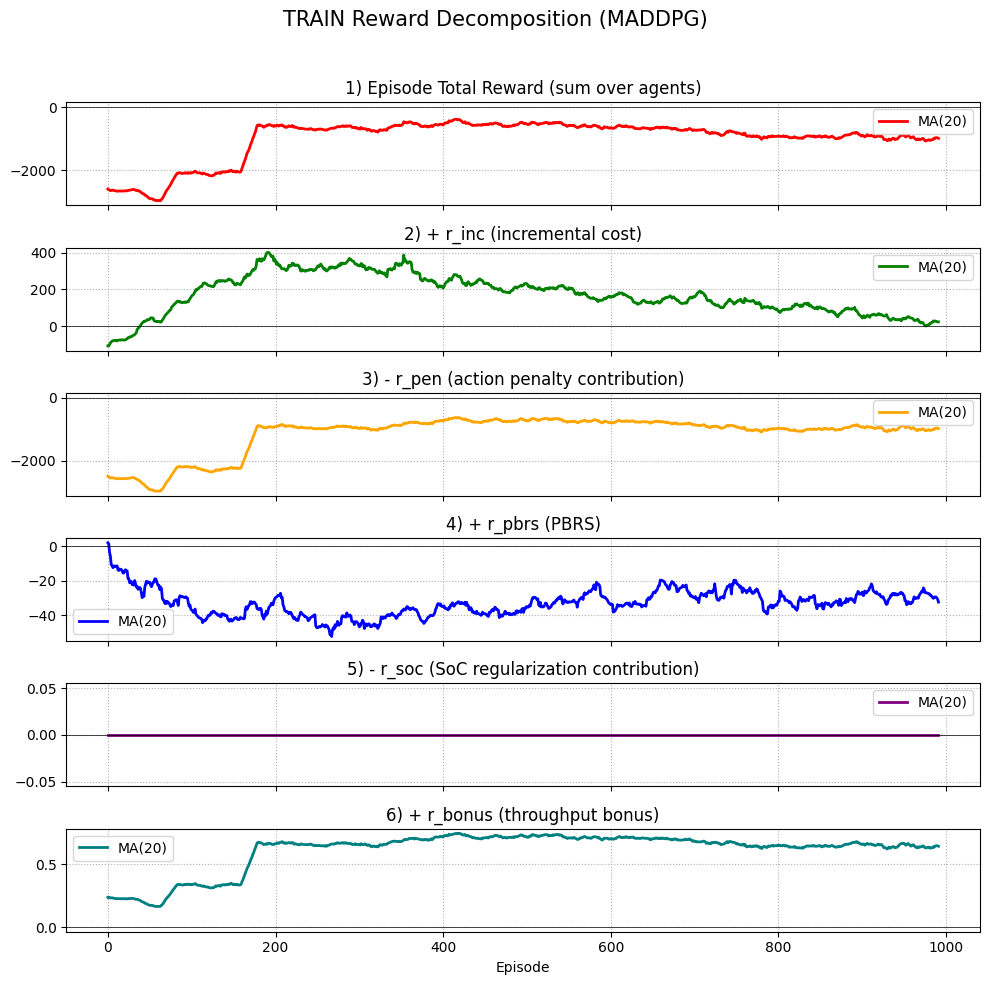

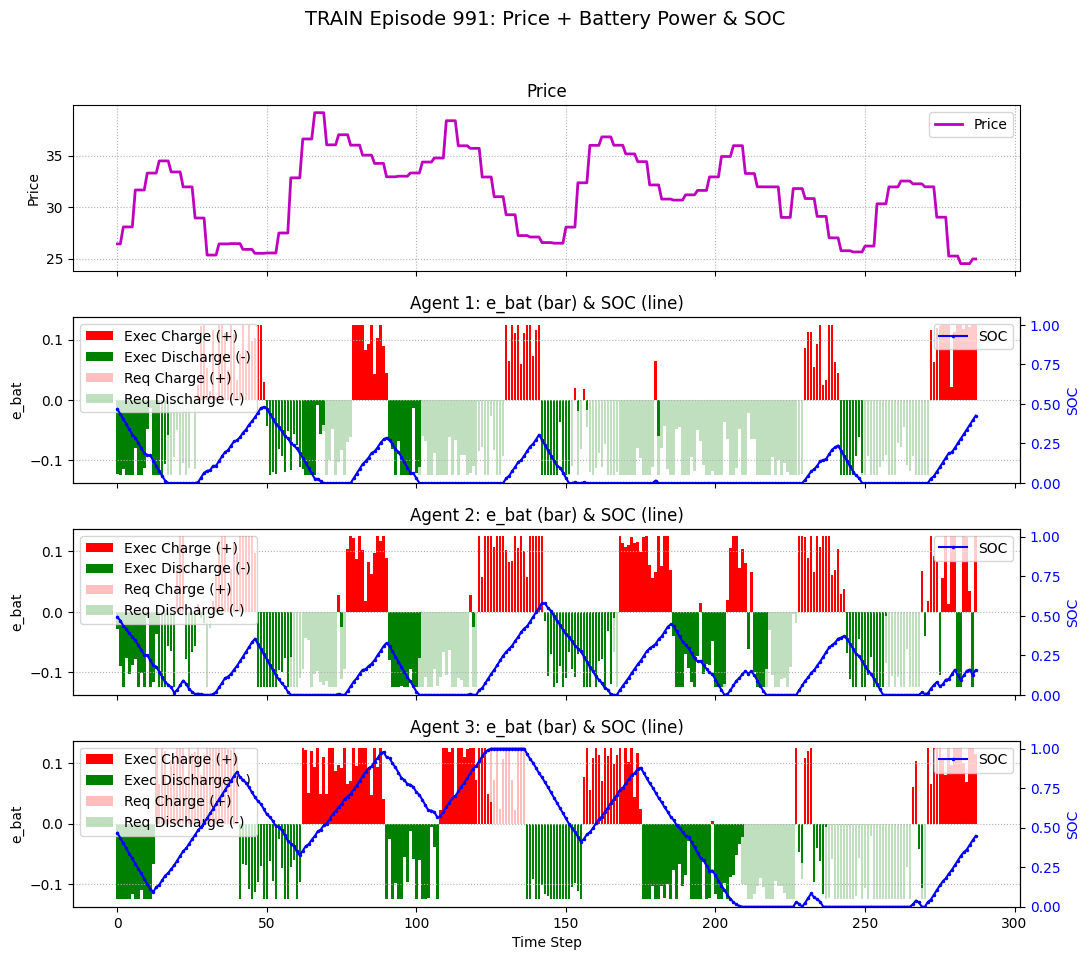

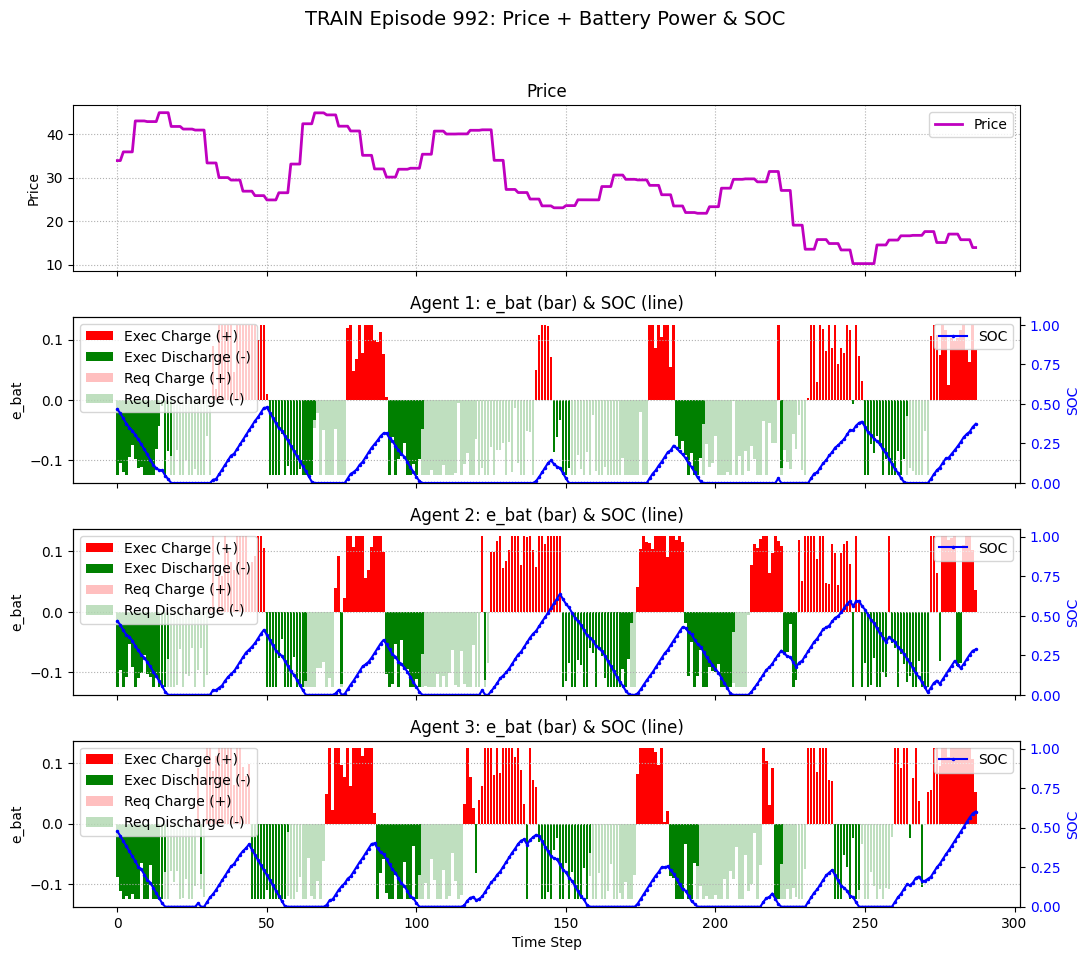

In [12]:
# =========================
# 4) 训练后：reward 分解曲线
# =========================
plot_reward_decomposition(
    history=runner.history,
    episode_rewards=runner.episode_rewards,
    title=f"TRAIN Reward Decomposition ({args.algorithm})",
    window=20,
)

# =========================
# 5) 训练后：最后2代轨迹（电价 + e_bat柱状 + soc折线）
# =========================
plot_last_k_episodes_price_action_soc(
    history=runner.history,
    k=2,
    n_agents=args.N,
    title_prefix="TRAIN",
)
